In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from dataset import SuperResolutionDataset
from model_sr3 import SR3UNet, SR3SuperResolution

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Rebuild model exactly like in train_sr3.py ----
unet = SR3UNet(
    in_channels=1,
    cond_channels=1,
    base_channels=32,
    channel_mults=(1, 2, 4),
    time_emb_dim=256,
).to(device)

model = SR3SuperResolution(
    unet=unet,
    timesteps=1000,
    upscale_factor=5,
).to(device)

# Load checkpoint
state = torch.load("checkpoints_sr3/best_sr3_icjuqv8u.pth", map_location=device)
model.load_state_dict(state)
model.eval()
print("✓ Model loaded.")

✓ Model loaded.


In [3]:
val_ds = SuperResolutionDataset(
    lr_path="../../data/euclid_NIR_cosmos_41px_Y_20251124.npy",
    hr_path="../../data/jwst_cosmos_205px_F115W_20251124.npy",
    split="test",
    lr_crop_size=21,
    hr_crop_size=105,
    sample_fraction=1.0,   # full validation set
)

print(f"Validation set length: {len(val_ds)}")


Loading data in NUMPY format for split 'test'...
Fitting LR normalizer on NUMPY data...
Fitting HR normalizer on NUMPY data...
Validation set length: 6812


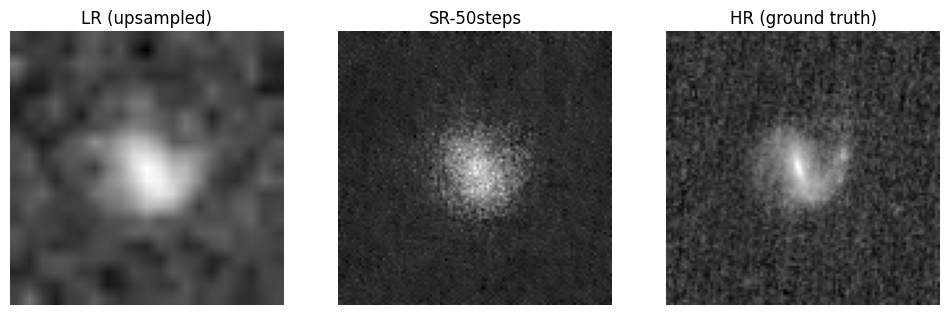

In [29]:
def viz(im):
    im = im.squeeze()
    vmin, vmax = im.min(), im.max()
    im = (im - vmin) / (vmax - vmin + 1e-6)
    return im

# Pick any index
idx = 251   # change to whichever looked interesting
lr, hr = val_ds[idx]

# Add batch dimension
lr = lr.unsqueeze(0).to(device)
hr = hr.unsqueeze(0).to(device)
numsteps=50
with torch.no_grad():
    # FULL 1000-step chain
    sr_full = model.sample(
        lr,
        num_steps=numsteps,        # <-- FULL diffusion schedule (all 1000)
        deterministic=True,    # <-- makes it DDIM-like / reproducible
    )[0].cpu()   # shape: (1, 105, 105)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("LR (upsampled)")
lr_up = F.interpolate(lr.cpu(), size=(105,105), mode="bilinear", align_corners=False)[0]
plt.imshow(viz(lr_up), cmap="gray")
plt.axis("off")

plt.subplot(1,3,2)
plt.title("SR-"+str(numsteps)+"steps")
plt.imshow(viz(sr_full), cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("HR (ground truth)")
plt.imshow(viz(hr.cpu()), cmap="gray")
plt.axis("off")

plt.show()


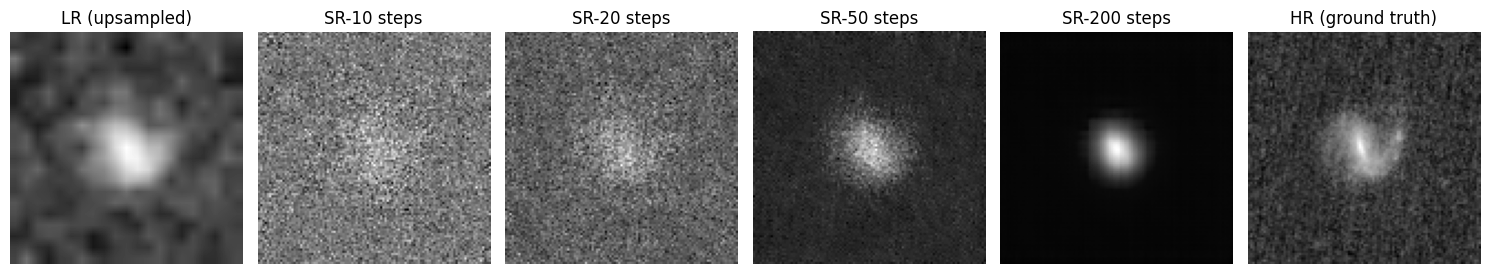

In [27]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

def viz(x):
    """Normalize an image to [0,1] for display."""
    x = x.squeeze()
    vmin, vmax = x.min(), x.max()
    return (x - vmin) / (vmax - vmin + 1e-8)

def diffusion_timestep_figure(model, val_ds, idx, steps=[10, 50, 500, 2000], figsize=(15,4)):
    """Plot LR → SR at different sampling depths → HR."""
    
    device = next(model.parameters()).device

    # load data
    lr, hr = val_ds[idx]
    lr = lr.unsqueeze(0).to(device)
    hr = hr.unsqueeze(0).to(device)

    # upsample LR for display
    lr_up = F.interpolate(lr, size=hr.shape[-2:], mode="bilinear", align_corners=False).cpu()[0]

    # run diffusion for each step count
    sr_list = []
    with torch.no_grad():
        for s in steps:
            sr = model.sample(
                lr,
                num_steps=s,
                deterministic=True     # DDIM-like sampling
            )[0].cpu()
            sr_list.append(sr)

    # ---- plotting ----
    ncols = 2 + len(steps)  # LR + (SRs) + HR
    plt.figure(figsize=figsize)

    # LR panel
    plt.subplot(1, ncols, 1)
    plt.title("LR (upsampled)")
    plt.imshow(viz(lr_up), cmap="gray")
    plt.axis("off")

    # SR panels
    for i, (s, sr) in enumerate(zip(steps, sr_list)):
        plt.subplot(1, ncols, i+2)
        plt.title(f"SR-{s} steps")
        plt.imshow(viz(sr), cmap="gray")
        plt.axis("off")

    # HR panel
    plt.subplot(1, ncols, ncols)
    plt.title("HR (ground truth)")
    plt.imshow(viz(hr.cpu()), cmap="gray")
    plt.axis("off")

    plt.tight_layout()
    plt.savefig("figure_2_ch3.png", dpi=300, bbox_inches="tight")
    plt.show()


# ---- Call the function ----
diffusion_timestep_figure(model, val_ds, idx=251, steps=[10, 20, 50, 200])


In [31]:
import numpy as np
import galsim
import torch
import torch.nn.functional as F

DEVICE = next(model.parameters()).device  # or torch.device("cuda"...) as appropriate

# --- pixel scales (set these to your actual values) ---
PIX_SCALE_LR = 0.3   # [arcsec/pix] e.g. Euclid NISP
PIX_SCALE_HR = 0.06  # [arcsec/pix] e.g. JWST NIRCam

# Initialize arrays to store moments
e1_lr, e2_lr, g1_lr, g2_lr = [], [], [], []
e1_hr, e2_hr, g1_hr, g2_hr = [], [], [], []
e1_sr, e2_sr, g1_sr, g2_sr = [], [], [], []


def get_moments(image_np, pixel_scale):
    """Return (e1, e2, g1, g2) from GalSim HSM. NaNs on failure."""
    try:
        # ensure float32 and 2D
        image_np = np.asarray(image_np, dtype=np.float32)

        ny, nx = image_np.shape
        img = galsim.ImageF(nx, ny, scale=pixel_scale)  # note: nx, ny ordering
        img.array[:, :] = image_np  # assign data

        res = galsim.hsm.FindAdaptiveMom(img)
        return [
            res.observed_e1,
            res.observed_e2,
            res.observed_shape.g1,
            res.observed_shape.g2,
        ]
    except Exception as e:
        # if you want, you can print the error once for debugging
        # print("HSM failure:", e)
        return [np.nan] * 4


# --- Loop over dataset ---
n_objects = min(2000, len(val_ds))  # safety
num_steps = 50  # or 1000; whatever sampling depth you want to test

for i in range(n_objects):
    lr_img, hr_img = val_ds[i]   # shapes: (1, H_lr, W_lr), (1, H_hr, W_hr)

    # to device with batch dim
    lr_batch = lr_img.unsqueeze(0).to(DEVICE)  # (1,1,H_lr,W_lr)

    with torch.no_grad():
        # SR sample on HR grid
        sr_batch = model.sample(
            lr_batch,
            num_steps=num_steps,
            deterministic=True,   # reproducible DDIM-like
            # init_sigma=1.0       # default; only override if you want
        )  # shape: (1,1,H_hr,W_hr)

    sr_img = sr_batch[0, 0].cpu().numpy()  # (H_hr, W_hr)

    # Convert LR and HR to numpy (2D)
    lr_np = lr_img[0].cpu().numpy()              # (H_lr, W_lr)
    hr_np = hr_img[0].cpu().numpy()              # (H_hr, W_hr)

    # Measure moments
    lr_vals = get_moments(lr_np, pixel_scale=PIX_SCALE_LR)
    hr_vals = get_moments(hr_np, pixel_scale=PIX_SCALE_HR)
    sr_vals = get_moments(sr_img, pixel_scale=PIX_SCALE_HR)

    e1_lr.append(lr_vals[0]); e2_lr.append(lr_vals[1]); g1_lr.append(lr_vals[2]); g2_lr.append(lr_vals[3])
    e1_hr.append(hr_vals[0]); e2_hr.append(hr_vals[1]); g1_hr.append(hr_vals[2]); g2_hr.append(hr_vals[3])
    e1_sr.append(sr_vals[0]); e2_sr.append(sr_vals[1]); g1_sr.append(sr_vals[2]); g2_sr.append(sr_vals[3])


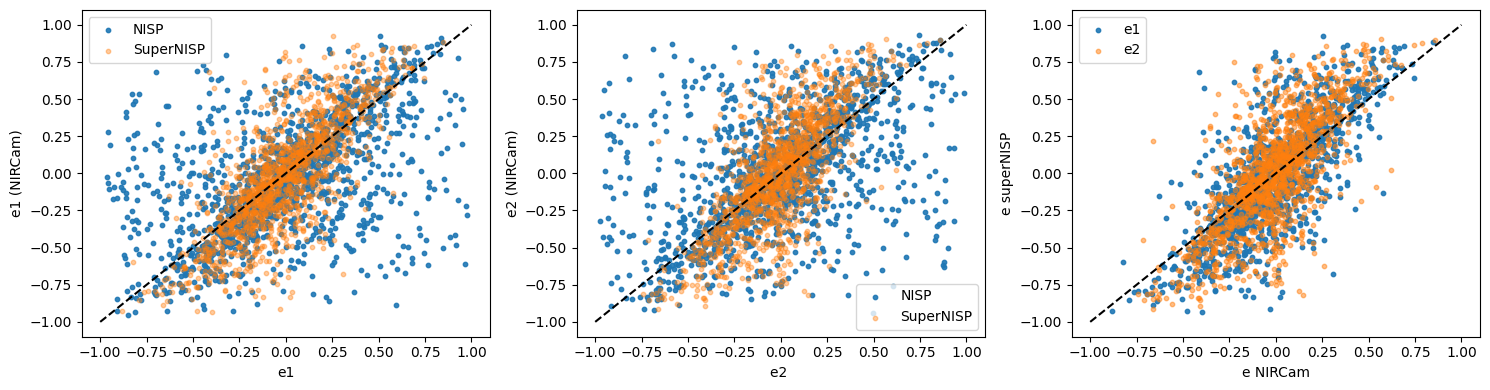

In [32]:
# Plot e1 and e2 comparisons
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].scatter(e1_lr, e1_hr, s=10, alpha=0.9, label='NISP')
axs[0].scatter(e1_sr, e1_hr, s=10, alpha=0.4, label='SuperNISP')
axs[0].plot([-1, 1], [-1, 1], 'k--')
axs[0].set_xlabel("e1")
axs[0].set_ylabel("e1 (NIRCam)")
axs[0].legend()

axs[1].scatter(e2_lr, e2_hr, s=10, alpha=0.9, label='NISP')
axs[1].scatter(e2_sr, e2_hr, s=10, alpha=0.4, label='SuperNISP')
axs[1].plot([-1, 1], [-1, 1], 'k--')
axs[1].set_xlabel("e2 ")
axs[1].set_ylabel("e2 (NIRCam)")
axs[1].legend()

axs[2].scatter(e1_sr, e1_hr, s=10, alpha=0.9, label='e1')
axs[2].scatter(e2_sr, e2_hr, s=10, alpha=0.5, label='e2')
axs[2].plot([-1, 1], [-1, 1], 'k--')
axs[2].set_xlabel("e NIRCam")
axs[2].set_ylabel("e superNISP")
axs[2].legend()

plt.tight_layout()
plt.show()


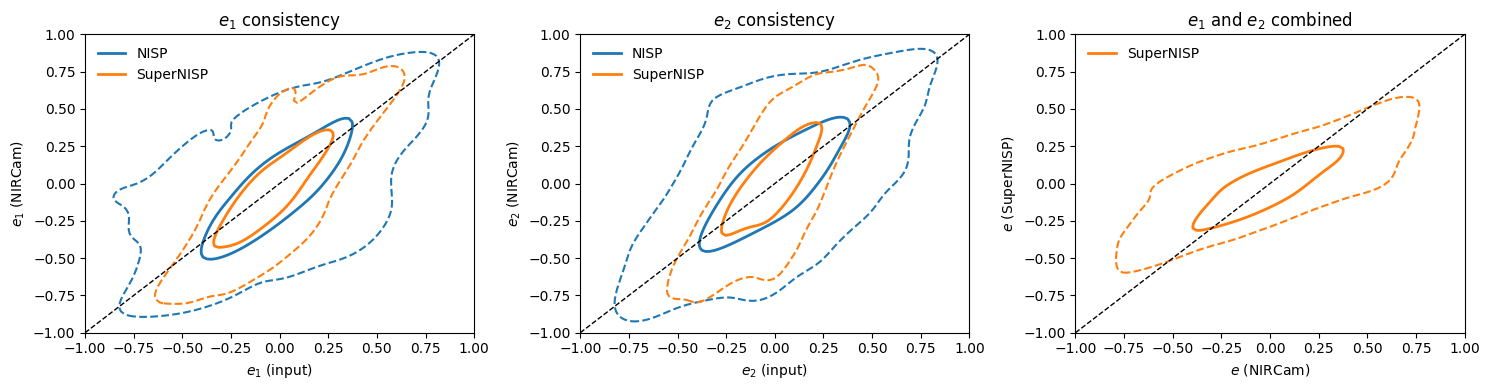

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde

# ensure arrays
e1_lr = np.asarray(e1_lr)
e2_lr = np.asarray(e2_lr)
e1_sr = np.asarray(e1_sr)
e2_sr = np.asarray(e2_sr)
e1_hr = np.asarray(e1_hr)
e2_hr = np.asarray(e2_hr)

def clean_xy(x, y):
    mask = np.isfinite(x) & np.isfinite(y)
    return x[mask], y[mask]

def kde_contours(ax, x, y, color, label, levels_prob=(0.393, 0.865),
                 gridsize=100, linewidths=(2.0, 1.5), linestyles=('-', '--')):
    """
    Draw 1- and 2-sigma style contours from 2D KDE.
    levels_prob = cumulative enclosed probabilities for contours.
    """
    x, y = clean_xy(x, y)
    if len(x) < 20:  # just in case
        return

    # Grid
    xmin, xmax = -1.0, 1.0
    ymin, ymax = -1.0, 1.0
    xx, yy = np.meshgrid(
        np.linspace(xmin, xmax, gridsize),
        np.linspace(ymin, ymax, gridsize)
    )
    positions = np.vstack([xx.ravel(), yy.ravel()])

    # KDE
    kde = gaussian_kde(np.vstack([x, y]))
    zz = kde(positions).reshape(xx.shape)

    # Convert PDF to enclosed probability levels
    z_flat = zz.ravel()
    z_sort = np.sort(z_flat)[::-1]
    cdf = np.cumsum(z_sort)
    cdf /= cdf[-1]

    def level_for_prob(p):
        return z_sort[np.searchsorted(cdf, p)]

    levels = [level_for_prob(p) for p in levels_prob]

    # Contours
    for lev, lw, ls in zip(levels, linewidths, linestyles):
        ax.contour(xx, yy, zz, levels=[lev],
                   colors=[color], linewidths=lw, linestyles=ls)

    # For legend: return a handle for the 1σ solid line
    return Line2D([0], [0], color=color, lw=linewidths[0], ls=linestyles[0],
                  label=label)

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

# --- Panel 1: e1 vs e1_NIRCam ---
handle_nisp = kde_contours(axs[0], e1_lr, e1_hr, color='tab:blue', label='NISP')
handle_sr   = kde_contours(axs[0], e1_sr, e1_hr, color='tab:orange', label='SuperNISP')

axs[0].plot([-1, 1], [-1, 1], 'k--', lw=1)
axs[0].set_xlim(-1, 1)
axs[0].set_ylim(-1, 1)
axs[0].set_xlabel(r"$e_1$ (input)")
axs[0].set_ylabel(r"$e_1$ (NIRCam)")
axs[0].legend(handles=[handle_nisp, handle_sr], loc='upper left', frameon=False)
axs[0].set_title(r"$e_1$ consistency")

# --- Panel 2: e2 vs e2_NIRCam ---
handle_nisp2 = kde_contours(axs[1], e2_lr, e2_hr, color='tab:blue', label='NISP')
handle_sr2   = kde_contours(axs[1], e2_sr, e2_hr, color='tab:orange', label='SuperNISP')

axs[1].plot([-1, 1], [-1, 1], 'k--', lw=1)
axs[1].set_xlim(-1, 1)
axs[1].set_ylim(-1, 1)
axs[1].set_xlabel(r"$e_2$ (input)")
axs[1].set_ylabel(r"$e_2$ (NIRCam)")
axs[1].legend(handles=[handle_nisp2, handle_sr2], loc='upper left', frameon=False)
axs[1].set_title(r"$e_2$ consistency")

# --- Panel 3: combined e1,e2 SuperNISP vs NIRCam ---
# Stack both components so you get more points and smoother contours
e_hr_all = np.concatenate([e1_hr, e2_hr])
e_sr_all = np.concatenate([e1_sr, e2_sr])

handle_comb = kde_contours(axs[2], e_hr_all, e_sr_all,
                           color='tab:orange', label='SuperNISP')

axs[2].plot([-1, 1], [-1, 1], 'k--', lw=1)
axs[2].set_xlim(-1, 1)
axs[2].set_ylim(-1, 1)
axs[2].set_xlabel(r"$e$ (NIRCam)")
axs[2].set_ylabel(r"$e$ (SuperNISP)")
axs[2].legend(handles=[handle_comb], loc='upper left', frameon=False)
axs[2].set_title(r"$e_1$ and $e_2$ combined")

plt.tight_layout()
plt.show()


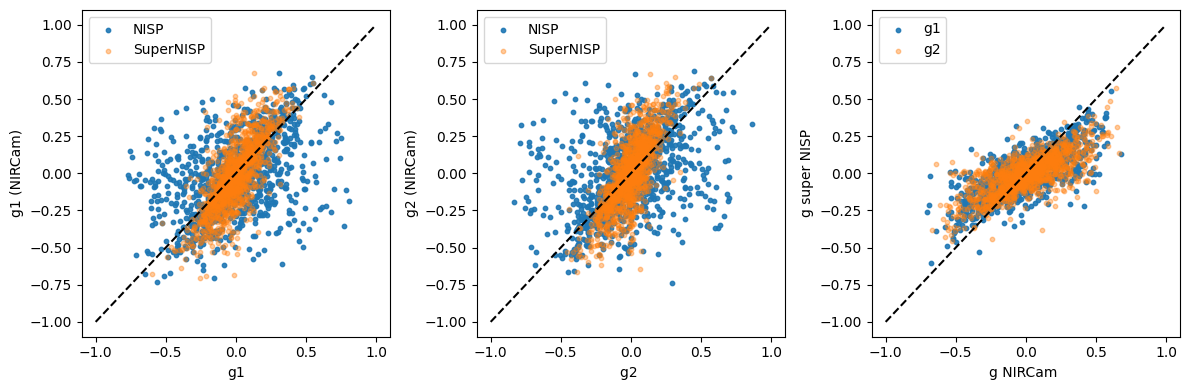

In [33]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

axs[0].scatter(g1_lr, g1_hr, s=10, alpha=0.9, label='NISP')
axs[0].scatter(g1_sr, g1_hr, s=10, alpha=0.4, label='SuperNISP')
axs[0].plot([-1, 1], [-1, 1], 'k--')
axs[0].set_xlabel("g1")
axs[0].set_ylabel("g1 (NIRCam)")
axs[0].legend()

axs[1].scatter(g2_lr, g2_hr, s=10, alpha=0.9, label='NISP')
axs[1].scatter(g2_sr, g2_hr, s=10, alpha=0.4, label='SuperNISP')
axs[1].plot([-1, 1], [-1, 1], 'k--')
axs[1].set_xlabel("g2 ")
axs[1].set_ylabel("g2 (NIRCam)")
axs[1].legend()

axs[2].scatter(g1_hr, g1_sr, s=10, alpha=0.9, label='g1')
axs[2].scatter(g2_hr, g2_sr, s=10, alpha=0.4, label='g2')
axs[2].plot([-1, 1], [-1, 1], 'k--')
axs[2].set_xlabel("g NIRCam ")
axs[2].set_ylabel("g super NISP")
axs[2].legend()

plt.tight_layout()
plt.show()


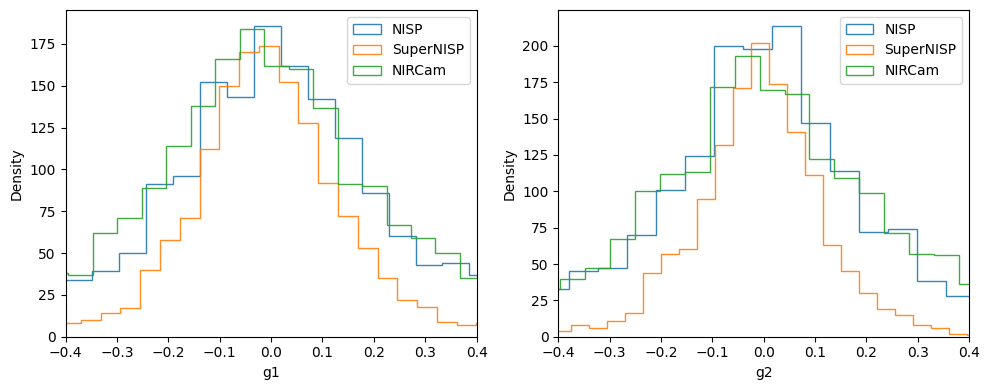

In [34]:

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# Histogram for g1
axs[0].hist(g1_lr, bins=30, alpha=0.9, label='NISP',histtype='step')
axs[0].hist(g1_sr, bins=30, alpha=0.9, label='SuperNISP',histtype='step')
axs[0].hist(g1_hr, bins=30, alpha=0.9, label='NIRCam',histtype='step')
axs[0].set_xlabel("g1")
axs[0].set_ylabel("Density")
axs[0].legend()

# Histogram for g2
axs[1].hist(g2_lr, bins=30, alpha=0.9, label='NISP',histtype='step')
axs[1].hist(g2_sr, bins=30, alpha=0.9, label='SuperNISP',histtype='step')
axs[1].hist(g2_hr, bins=30, alpha=0.9, label='NIRCam',histtype='step')
axs[1].set_xlabel("g2")
axs[1].set_ylabel("Density")
axs[1].legend()
axs[1].set_xlim([-0.4,0.4])
axs[0].set_xlim([-0.4,0.4])

plt.tight_layout()
plt.show()
